# ARTI308 - Machine Learning Lab 3

### 1. Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler, StandardScaler 
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

### 2. Load Dataset

In [2]:
df = pd.read_csv("Smartphone_Usage_Productivity_Dataset_50000.csv")

num_cols = ['Age', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level', 'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'] 
data = df[num_cols]

### Task 1: Identify data quality issues

In [3]:
print("Dataset Info:")
print(data.info())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        50000 non-null  int64  
 1   Daily_Phone_Hours          50000 non-null  float64
 2   Social_Media_Hours         50000 non-null  float64
 3   Work_Productivity_Score    50000 non-null  int64  
 4   Sleep_Hours                50000 non-null  float64
 5   Stress_Level               50000 non-null  int64  
 6   App_Usage_Count            50000 non-null  int64  
 7   Caffeine_Intake_Cups       50000 non-null  int64  
 8   Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5)
memory usage: 3.4 MB
None


In [4]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
Age                          0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64


### Task 2: Missing Value Strategy

In [5]:
data_filled = data.copy()
for col in data_filled.columns: 
    if data_filled[col].isnull().sum() > 0: 
        data_filled[col].fillna(data_filled[col].mean(), inplace=True)

### Task 3: Detect and Handle Outliers using IQR

In [6]:
Q1 = data_filled.quantile(0.25) 
Q3 = data_filled.quantile(0.75) 
IQR = Q3 - Q1 
lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR

data_clean = data_filled[~((data_filled < lower_bound) | (data_filled > upper_bound)).any(axis=1)]

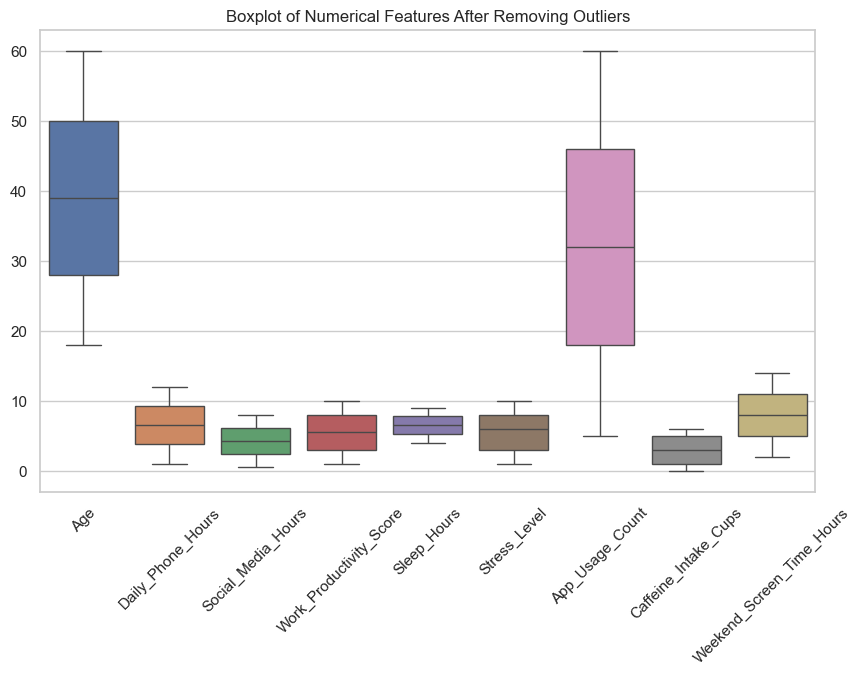

In [7]:
plt.figure(figsize=(10,6)) 
sns.boxplot(data=data_clean) 
plt.title("Boxplot of Numerical Features After Removing Outliers") 
plt.xticks(rotation=45) 
plt.show()

### Task 4: Normalize numerical features

In [8]:
scaler_minmax = MinMaxScaler() 
data_minmax = pd.DataFrame(scaler_minmax.fit_transform(data_clean), columns=data_clean.columns)

In [9]:
scaler_std = StandardScaler() 
data_zscore = pd.DataFrame(scaler_std.fit_transform(data_clean), columns=data_clean.columns)

print("\nSample of Z-score Normalized Data:")


Sample of Z-score Normalized Data:


In [10]:
print(data_zscore.head())

        Age  Daily_Phone_Hours  Social_Media_Hours  Work_Productivity_Score  \
0  1.527621          -1.642803            1.123817                 0.172619   
1 -1.130507          -1.674340           -1.278340                -0.175234   
2 -1.613803          -0.381320            0.661863                -0.175234   
3 -0.325013          -0.223634           -0.816387                -1.218793   
4 -0.486112           0.438644           -1.370731                -0.523087   

   Sleep_Hours  Stress_Level  App_Usage_Count  Caffeine_Intake_Cups  \
0     1.588271     -0.524021         0.593066             -1.003978   
1    -0.067431     -1.568929         1.151332             -0.002294   
2     1.726246     -0.524021        -1.143762              0.999391   
3    -0.550344     -0.872324         0.220888              1.500233   
4    -0.550344     -0.872324         0.282918              0.999391   

   Weekend_Screen_Time_Hours  
0                   0.200261  
1                  -0.839821  
2    

### Task 5: Apply PCA and interpret

In [11]:
pca = PCA(n_components=2) 
pca_components = pca.fit_transform(data_zscore)

explained_variance = pca.explained_variance_ratio_ 
print(f"Explained Variance Ratio: {explained_variance}") 
print(f"Total variance explained by first 2 components: {sum(explained_variance):.2f}")

Explained Variance Ratio: [0.11353555 0.11259886]
Total variance explained by first 2 components: 0.23


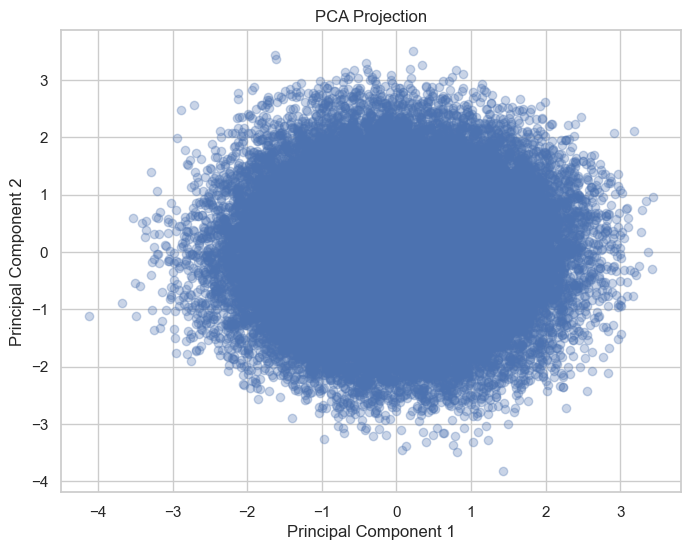

In [12]:
plt.figure(figsize=(8,6)) 
plt.scatter(pca_components[:,0], pca_components[:,1], alpha=0.3) 
plt.xlabel('Principal Component 1') 
plt.ylabel('Principal Component 2') 
plt.title('PCA Projection') 
plt.show()